# Options Trading Cheat Sheet
### Focus: Crude Oil · LNG · Coal

This notebook covers:
1. Core option types (vanilla calls & puts)
2. Every major strategy — payoff diagrams & when to use
3. Commodity-specific context (crude oil, LNG, coal)
4. **Strategy selector calculator** — enter your market view and it recommends the right trade

> Companion notebooks: `options_greeks_cheatsheet.ipynb` (Greeks) · `black_scholes_commodities.ipynb` (pricing)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

# ── Black-Scholes core ──────────────────────────────────────────────────────
def d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    _d1, _d2 = d1(S,K,T,r,sigma), d2(S,K,T,r,sigma)
    return S * norm.cdf(_d1) - K * np.exp(-r*T) * norm.cdf(_d2)

def bs_put(S, K, T, r, sigma):
    _d1, _d2 = d1(S,K,T,r,sigma), d2(S,K,T,r,sigma)
    return K * np.exp(-r*T) * norm.cdf(-_d2) - S * norm.cdf(-_d1)

print("Setup complete.")

Setup complete.


---
## Part 1 — Option Types

### 1.1 The Two Vanilla Building Blocks

| | **Call Option** | **Put Option** |
|---|---|---|
| Right to | **Buy** underlying at strike K | **Sell** underlying at strike K |
| Buyer pays | Premium (upfront) | Premium (upfront) |
| Buyer profits when | Price **rises above** K + premium | Price **falls below** K − premium |
| Max loss (buyer) | Premium paid | Premium paid |
| Max gain (buyer) | Unlimited | K − premium (price can't go below 0) |
| Seller profits when | Price stays **below** K | Price stays **above** K |
| Max gain (seller) | Premium received | Premium received |
| Max loss (seller) | Unlimited | K − premium |

### 1.2 Moneyness

| Status | Call | Put | Has intrinsic value? |
|---|---|---|---|
| **ITM** (In-the-Money) | S > K | S < K | Yes |
| **ATM** (At-the-Money) | S ≈ K | S ≈ K | Borderline |
| **OTM** (Out-of-the-Money) | S < K | S > K | No — pure time value |

### 1.3 Exercise Style

| Style | Exercise timing | Common in |
|---|---|---|
| **European** | Expiry only | Index options, commodity futures options |
| **American** | Any time before expiry | Equity options, CME energy options |
| **Bermudan** | On specified dates | Structured energy deals, swaps with optionality |

> Crude oil options on CME are **American-style** on futures. LNG is mostly **OTC European** or Asian (average-price).

### 1.4 Option Taxonomy

```
Options
├── Vanilla (standard)
│   ├── Call
│   └── Put
└── Exotic
    ├── Asian (Average-price)  ← dominant in LNG & coal physical hedging
    ├── Barrier (knock-in / knock-out)  ← cheaper premium for defined risk windows
    ├── Digital / Binary  ← fixed payout if condition met
    ├── Spread option  ← crack spread (oil), dark spread (coal/power), spark spread
    ├── Calendar spread option  ← contango/backwardation bets
    └── Compound option  ← option on an option (used in project finance)
```

---

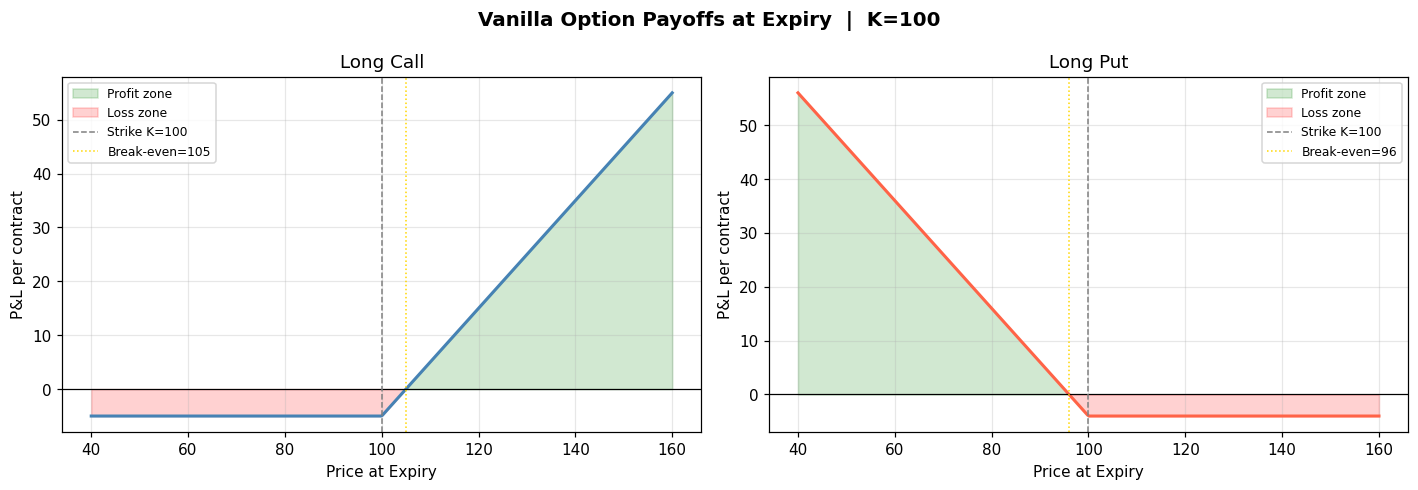

In [2]:
# ── Payoff diagram: Long Call vs Long Put ───────────────────────────────────
S = np.linspace(40, 160, 400)
K, prem_c, prem_p = 100, 5, 4

long_call = np.maximum(S - K, 0) - prem_c
long_put  = np.maximum(K - S, 0) - prem_p

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, pnl, label, color, be in [
    (axes[0], long_call, 'Long Call',  'steelblue',  K + prem_c),
    (axes[1], long_put,  'Long Put',   'tomato',     K - prem_p),
]:
    ax.plot(S, pnl, color=color, lw=2)
    ax.fill_between(S, pnl, 0, where=(pnl > 0), alpha=0.18, color='green', label='Profit zone')
    ax.fill_between(S, pnl, 0, where=(pnl < 0), alpha=0.18, color='red',   label='Loss zone')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(K,  color='gray',  lw=1, linestyle='--', label=f'Strike K={K}')
    ax.axvline(be, color='gold',  lw=1, linestyle=':',  label=f'Break-even={be}')
    ax.set_xlabel('Price at Expiry')
    ax.set_ylabel('P&L per contract')
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle('Vanilla Option Payoffs at Expiry  |  K=100', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2 — Strategy Reference

### 2.1 Strategy Quick-Reference Table

| Strategy | Legs | Market View | Max Loss | Max Profit | Break-even |
|---|---|---|---|---|---|
| Long Call | +1 call | Bullish, vol rising | Premium | Unlimited | K + C |
| Short Call (naked) | −1 call | Bearish / neutral | Unlimited | Premium | K + C |
| Long Put | +1 put | Bearish, vol rising | Premium | K − P | K − P |
| Short Put | −1 put | Bullish / neutral | K − P | Premium | K − P |
| Bull Call Spread | +1 call K₁, −1 call K₂ | Mild bullish | Net debit | K₂−K₁−debit | K₁ + debit |
| Bear Put Spread | +1 put K₂, −1 put K₁ | Mild bearish | Net debit | K₂−K₁−debit | K₂ − debit |
| Long Straddle | +1 call + 1 put (same K) | Big move, no direction | 2× premium | Unlimited | K±(C+P) |
| Short Straddle | −1 call − 1 put (same K) | Neutral, vol crush | Unlimited | C + P | K±(C+P) |
| Iron Condor | Bear call spread + Bull put spread | Range-bound | Width − credit | Net credit | See below |
| Long Strangle | +OTM call + OTM put | Big move (cheaper than straddle) | C + P | Unlimited | K_c+C or K_p−P |
| Covered Call | Long stock + −1 call | Mild bullish, income | Stock loss − C | (K−S₀)+C | S₀ − C |
| Protective Put | Long stock + +1 put | Long stock but want downside hedge | P + (S₀−K) | Unlimited | S₀ + P |
| Calendar Spread | −1 near-expiry + +1 far-expiry (same K) | Neutral near-term, long vol | Net debit | Theoretical | Near K at near expiry |
| Ratio Spread (1×2 call) | +1 ATM call, −2 OTM calls | Mild bullish, sell wing premium | Unlimited above K₂ | K₂−K₁−debit | K₁+debit or 2K₂−K₁−debit |

---

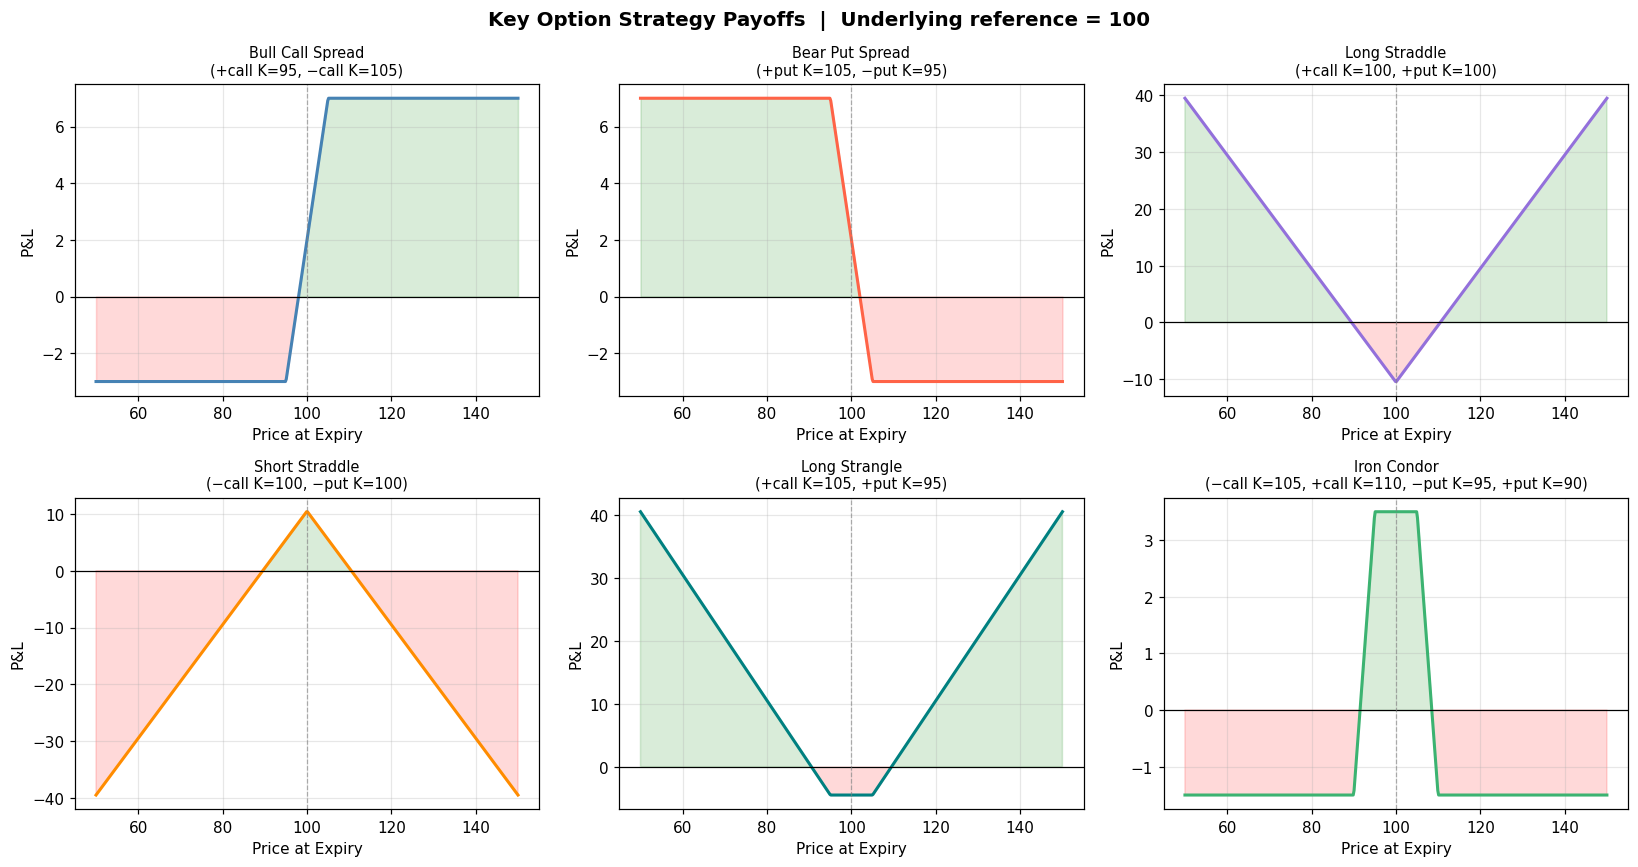

In [3]:
# ── Strategy payoff diagrams (6 key strategies) ─────────────────────────────
S = np.linspace(50, 150, 500)
K1, K2, K3, K4 = 90, 95, 105, 110
C_atm, P_atm = 5.5, 5.0
C_otm, P_otm = 2.5, 2.0

strategies = [
    ('Bull Call Spread\n(+call K=95, −call K=105)',
     np.maximum(S-K2,0) - np.maximum(S-K3,0) - (C_atm-C_otm),
     'steelblue'),
    ('Bear Put Spread\n(+put K=105, −put K=95)',
     np.maximum(K3-S,0) - np.maximum(K2-S,0) - (P_atm-P_otm),
     'tomato'),
    ('Long Straddle\n(+call K=100, +put K=100)',
     np.maximum(S-100,0) + np.maximum(100-S,0) - C_atm - P_atm,
     'mediumpurple'),
    ('Short Straddle\n(−call K=100, −put K=100)',
     -(np.maximum(S-100,0) + np.maximum(100-S,0)) + C_atm + P_atm,
     'darkorange'),
    ('Long Strangle\n(+call K=105, +put K=95)',
     np.maximum(S-K3,0) + np.maximum(K2-S,0) - C_otm - P_otm,
     'teal'),
    ('Iron Condor\n(−call K=105, +call K=110, −put K=95, +put K=90)',
     -(np.maximum(S-K3,0) - np.maximum(S-K4,0)) -
      (np.maximum(K2-S,0) - np.maximum(K1-S,0)) + C_otm + P_otm - 1.0,
     'mediumseagreen'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (title, pnl, color) in zip(axes.flat, strategies):
    ax.plot(S, pnl, color=color, lw=2)
    ax.fill_between(S, pnl, 0, where=(pnl>0), alpha=0.15, color='green')
    ax.fill_between(S, pnl, 0, where=(pnl<0), alpha=0.15, color='red')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(100, color='gray', lw=0.8, linestyle='--', alpha=0.6)
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel('Price at Expiry')
    ax.set_ylabel('P&L')

fig.suptitle('Key Option Strategy Payoffs  |  Underlying reference = 100', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Commodity Context

### 3.1 Crude Oil

| Attribute | Detail |
|---|---|
| **Benchmarks** | WTI (NYMEX/CME), Brent (ICE) |
| **Contract size** | 1,000 barrels |
| **Listed options** | American-style calls & puts on futures; weekly + monthly expiries |
| **Typical IV** | 25–50% (spikes to 80%+ during geopolitical shocks) |
| **Key drivers** | OPEC+ supply decisions, US EIA inventory, geopolitics, demand outlook |
| **Common strategies** | Collars (producer hedges), call spreads (refiner input hedge), put spread (airline fuel hedge) |
| **Asian options** | Heavily used by physical traders — settled on monthly average price (MOPS, Platts) |

**Producer hedging example:** A shale producer with $60/bbl breakeven buys a WTI put spread:
- Buy 6-month put at $65 (ATM)
- Sell 6-month put at $50 (OTM) → reduces premium cost
- Net cost: ~$2/bbl | Protected down to $50, exposed below that

### 3.2 LNG (Liquefied Natural Gas)

| Attribute | Detail |
|---|---|
| **Benchmarks** | JKM (Japan-Korea Marker, Platts), TTF (Europe), Henry Hub (US) |
| **Contract** | Mostly OTC; CME JKM futures exist but liquidity is thin |
| **Option style** | Primarily OTC European & Asian (monthly average) |
| **Typical IV** | 50–100%+ (highly seasonal; winter spikes) |
| **Key drivers** | Asian demand (heating/cooling), European storage levels, US LNG export capacity, weather |
| **Common strategies** | Asian call options (buyer protection), collars, swing optionality (embedded in LT contracts) |
| **Special instruments** | **Swaptions** (option to enter a fixed-float gas price swap), **tolling agreements** |

**Buyer hedging example:** A Japanese utility buys JKM Asian call caps:
- Buy 3-month Asian call at $14/MMBtu
- Settled against monthly average JKM
- If avg JKM = $18 → receives $4/MMBtu payment → offsets physical cargo cost

### 3.3 Coal

| Attribute | Detail |
|---|---|
| **Benchmarks** | Newcastle FOB (ICE), API-2 (ARA, Europe), API-4 (Richards Bay, South Africa) |
| **Contract size** | 1,000 tonnes (ICE) |
| **Option style** | American-style on futures (ICE); OTC Asian also common |
| **Typical IV** | 30–70% (spikes during supply disruptions, energy transitions) |
| **Key drivers** | China/India demand, Australian/Indonesian supply, carbon prices, natural gas substitution |
| **Common strategies** | **Dark spread options** (coal vs power price), put spreads (producer hedges), call spreads (utility input hedges) |
| **Dark spread** | Power price − (coal price × heat rate) — option on the margin of a coal-fired plant |

**Utility hedging example:** A European power generator buys a coal call spread:
- Buy 6-month API-2 call at $120/t
- Sell 6-month API-2 call at $150/t
- Max payout: $30/t if coal exceeds $150; cost capped

### 3.4 Commodity IV Comparison

```
Commodity     | Typical IV range | What drives spikes
─────────────────────────────────────────────────────────
Crude Oil WTI | 25–55%          | OPEC meetings, geopolitics, inventory surprises
LNG / JKM     | 50–100%+        | Winter cold snaps, supply outages, Asian demand
Coal API-2    | 30–65%          | China demand shifts, mining disruptions, EU carbon price
Coal Newcastle| 35–70%          | Australia weather, Indonesian export policy
```

> **High IV → expensive options.** When IV is elevated, prefer selling premium (spreads, iron condors) or buying spreads over outright options. When IV is crushed, buy straddles/strangles anticipating vol expansion.

---

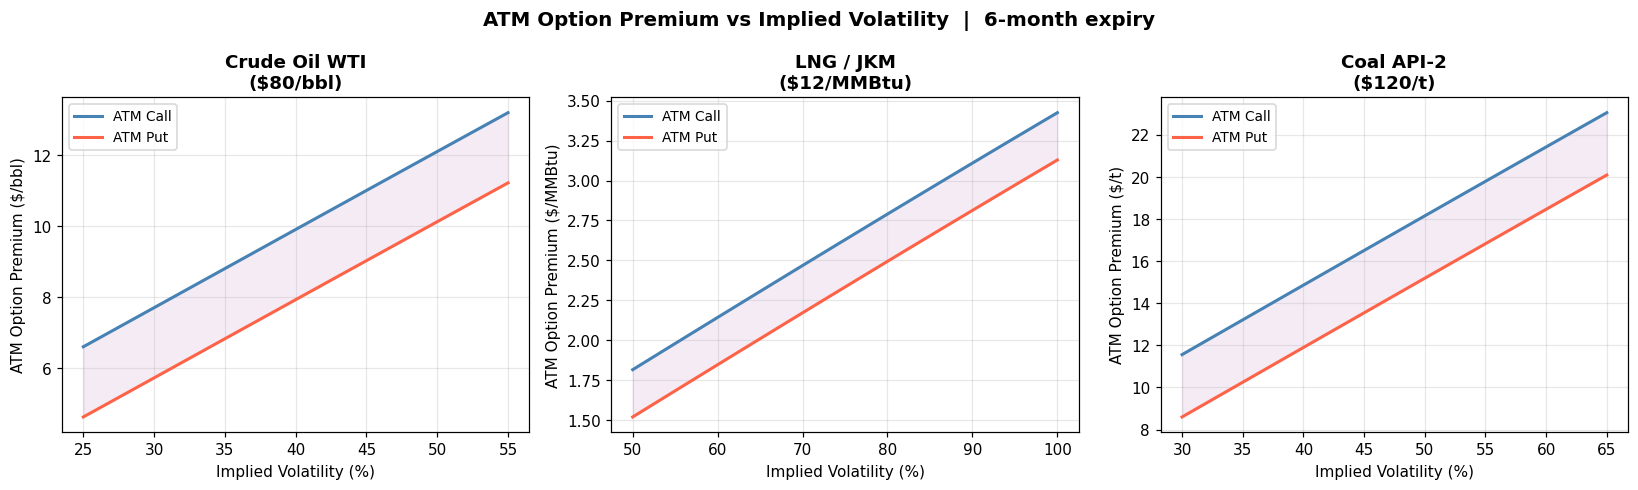

In [4]:
# ── How IV affects option cost (commodity context) ───────────────────────────
T, r = 0.5, 0.05  # 6-month options

# Representative mid-prices for each commodity
commodities = {
    'Crude Oil WTI\n($80/bbl)':   {'S': 80,   'iv_range': (0.25, 0.55), 'unit': '$/bbl'},
    'LNG / JKM\n($12/MMBtu)':     {'S': 12,   'iv_range': (0.50, 1.00), 'unit': '$/MMBtu'},
    'Coal API-2\n($120/t)':        {'S': 120,  'iv_range': (0.30, 0.65), 'unit': '$/t'},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, params) in zip(axes, commodities.items()):
    S0 = params['S']
    iv_lo, iv_hi = params['iv_range']
    ivs = np.linspace(iv_lo, iv_hi, 100)

    call_atm = [bs_call(S0, S0, T, r, iv) for iv in ivs]
    put_atm  = [bs_put(S0, S0, T, r, iv)  for iv in ivs]

    ax.plot(ivs*100, call_atm, label='ATM Call', color='steelblue', lw=2)
    ax.plot(ivs*100, put_atm,  label='ATM Put',  color='tomato',    lw=2)
    ax.fill_between(ivs*100, call_atm, put_atm, alpha=0.08, color='purple')
    ax.set_xlabel('Implied Volatility (%)')
    ax.set_ylabel(f'ATM Option Premium ({params["unit"]})')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('ATM Option Premium vs Implied Volatility  |  6-month expiry', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — Strategy Selector Calculator

**How to use:** Edit the input variables in the cell below, then run it.
The calculator takes your market view and risk parameters and scores every strategy.

### Inputs explained

| Parameter | What to enter |
|---|---|
| `commodity` | `'crude_oil'`, `'lng'`, or `'coal'` |
| `current_price` | Today's spot/futures price |
| `price_target` | Your expected price at expiry (or worst-case/best-case) |
| `direction` | `'bullish'`, `'bearish'`, or `'neutral'` |
| `conviction` | `'strong'` (big move) or `'mild'` (modest move) |
| `vol_view` | `'rising'` (expect IV to go up), `'falling'` (expect IV crush), `'neutral'` |
| `horizon_months` | Option expiry in months |
| `risk_tolerance` | `'limited'` (defined max loss), `'unlimited'` (can take naked exposure) |
| `role` | `'producer'`, `'consumer'`, `'trader'`, or `'speculator'` |
| `budget_pct` | Max premium as % of current price you're willing to pay (e.g. 3 = 3%) |

---

In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║              STRATEGY SELECTOR ENGINE                               ║
# ╚══════════════════════════════════════════════════════════════════════╝

COMMODITY_DEFAULTS = {
    'crude_oil': {'name': 'Crude Oil (WTI)', 'iv': 0.35, 'unit': '$/bbl',    'contract': '1,000 bbl (CME)'},
    'lng':       {'name': 'LNG / JKM',       'iv': 0.70, 'unit': '$/MMBtu',  'contract': 'OTC / CME JKM'},
    'coal':      {'name': 'Coal (API-2)',     'iv': 0.45, 'unit': '$/t',      'contract': '1,000 t (ICE)'},
}

def calc_strategy_cost(S, K, T, r, iv, strategy):
    """Return approximate net premium (positive = debit, negative = credit)"""
    c_atm  = bs_call(S, S*1.00, T, r, iv)
    p_atm  = bs_put( S, S*1.00, T, r, iv)
    c_5otm = bs_call(S, S*1.05, T, r, iv)
    p_5otm = bs_put( S, S*0.95, T, r, iv)
    c_10otm= bs_call(S, S*1.10, T, r, iv)
    p_10otm= bs_put( S, S*0.90, T, r, iv)

    costs = {
        'Long Call':            c_atm,
        'Short Call':          -c_atm,
        'Long Put':             p_atm,
        'Short Put':           -p_atm,
        'Bull Call Spread':     c_atm  - c_5otm,
        'Bear Put Spread':      p_atm  - p_5otm,
        'Long Straddle':        c_atm  + p_atm,
        'Short Straddle':      -(c_atm + p_atm),
        'Long Strangle':        c_5otm + p_5otm,
        'Short Strangle':      -(c_5otm + p_5otm),
        'Iron Condor':         -(c_5otm - c_10otm + p_5otm - p_10otm),
        'Collar (producer)':    p_atm  - c_5otm,
        'Protective Put':       p_5otm,
        'Covered Call':        -c_5otm,
        'Calendar Spread':      c_atm * 0.35,    # approx back-front spread
    }
    return costs.get(strategy, 0.0)


def score_strategies(direction, conviction, vol_view, risk_tolerance, role, S, budget_pct, T, iv, r=0.05):
    """
    Score each strategy 0-10 based on the user's market view.
    Returns list of (score, strategy_name, rationale, cost, cost_pct_S).
    """
    strategies = [
        'Long Call', 'Short Call', 'Long Put', 'Short Put',
        'Bull Call Spread', 'Bear Put Spread',
        'Long Straddle', 'Short Straddle',
        'Long Strangle', 'Short Strangle',
        'Iron Condor', 'Collar (producer)', 'Protective Put', 'Covered Call',
        'Calendar Spread',
    ]

    # ── scoring matrix ──────────────────────────────────────────────────
    # Each factor adds/subtracts points toward a 10-point scale
    scores = {s: 5.0 for s in strategies}  # start neutral

    # --- direction ---
    if direction == 'bullish':
        for s in ['Long Call', 'Bull Call Spread', 'Short Put', 'Covered Call']: scores[s] += 2
        for s in ['Long Put',  'Bear Put Spread',  'Short Call']:                scores[s] -= 3
        for s in ['Collar (producer)', 'Protective Put']:                        scores[s] -= 1
    elif direction == 'bearish':
        for s in ['Long Put',   'Bear Put Spread', 'Short Call']:                scores[s] += 2
        for s in ['Long Call',  'Bull Call Spread','Short Put']:                 scores[s] -= 3
        for s in ['Collar (producer)', 'Protective Put']:                        scores[s] += 1.5
    else:  # neutral
        for s in ['Short Straddle', 'Short Strangle', 'Iron Condor', 'Calendar Spread']: scores[s] += 2
        for s in ['Long Straddle',  'Long Strangle']:                                     scores[s] -= 1
        for s in ['Long Call', 'Long Put', 'Bull Call Spread', 'Bear Put Spread']:       scores[s] -= 2

    # --- conviction ---
    if conviction == 'strong':
        for s in ['Long Call', 'Long Put']:                            scores[s] += 1.5
        for s in ['Bull Call Spread', 'Bear Put Spread']:              scores[s] -= 0.5
        for s in ['Iron Condor', 'Short Straddle', 'Short Strangle']: scores[s] -= 2
    else:  # mild
        for s in ['Bull Call Spread', 'Bear Put Spread', 'Covered Call', 'Short Put']: scores[s] += 1
        for s in ['Long Call', 'Long Put']:                                             scores[s] -= 0.5

    # --- vol view ---
    if vol_view == 'rising':
        for s in ['Long Call', 'Long Put', 'Long Straddle', 'Long Strangle']: scores[s] += 2
        for s in ['Short Straddle', 'Short Strangle', 'Iron Condor']:         scores[s] -= 3
        for s in ['Calendar Spread']:                                          scores[s] += 1
    elif vol_view == 'falling':
        for s in ['Short Straddle', 'Short Strangle', 'Iron Condor']:         scores[s] += 2
        for s in ['Long Call', 'Long Put', 'Long Straddle', 'Long Strangle']: scores[s] -= 2
        for s in ['Calendar Spread']:                                          scores[s] -= 1

    # --- risk tolerance ---
    if risk_tolerance == 'limited':
        for s in ['Short Call', 'Short Put', 'Short Straddle', 'Short Strangle']: scores[s] -= 3
        for s in ['Bull Call Spread', 'Bear Put Spread', 'Iron Condor']:           scores[s] += 1
        for s in ['Collar (producer)', 'Protective Put']:                          scores[s] += 1.5
    else:
        for s in ['Short Call', 'Short Straddle', 'Short Strangle']: scores[s] += 0.5

    # --- role ---
    if role == 'producer':
        for s in ['Collar (producer)', 'Long Put', 'Bear Put Spread']: scores[s] += 2
        for s in ['Short Call', 'Covered Call']:                        scores[s] += 0.5
    elif role == 'consumer':
        for s in ['Long Call', 'Bull Call Spread', 'Protective Put']:  scores[s] += 2
        for s in ['Short Put']:                                         scores[s] += 0.5
    elif role == 'trader':
        for s in ['Bull Call Spread', 'Bear Put Spread', 'Iron Condor',
                  'Calendar Spread', 'Long Strangle']:                  scores[s] += 1

    # --- budget filter: penalize strategies too expensive ---
    budget_abs = S * budget_pct / 100
    results = []
    for strat in strategies:
        cost = calc_strategy_cost(S, S, T, r, iv, strat)
        cost_pct = abs(cost) / S * 100
        score = scores[strat]

        if cost > 0 and cost > budget_abs * 1.5:
            score -= 2  # over budget

        # build rationale
        parts = []
        if score >= 7:  parts.append('Strong fit')
        elif score >= 5: parts.append('Moderate fit')
        else:            parts.append('Poor fit')

        cost_label = f"{'+' if cost>0 else ''}{cost:.2f} ({'debit' if cost>0 else 'credit'})"
        results.append((min(10, max(0, round(score, 1))), strat, cost_label, cost, cost_pct))

    return sorted(results, reverse=True)


RATIONALES = {
    'Long Call':         'Unlimited upside, defined loss (premium). Best when strongly bullish and expecting IV to rise.',
    'Short Call':        'Collect premium; profit if price stays below strike. Unlimited upside risk — use with care.',
    'Long Put':          'Unlimited downside protection, defined cost. Best hedge for bearish view or downside protection.',
    'Short Put':         'Collect premium if price stays above strike. Obligates you to buy at K — suit bullish / income.',
    'Bull Call Spread':  'Defined debit, defined max gain. Cheap directional bet when mildly bullish; limits upside.',
    'Bear Put Spread':   'Defined debit, defined max gain. Cheap directional hedge for mild bearish view.',
    'Long Straddle':     'Profits from large moves in either direction. Expensive — needs big realized vol vs. implied vol.',
    'Short Straddle':    'Collects maximum premium; profits if price stays pinned near strike. Naked risk both ways.',
    'Long Strangle':     'Cheaper than straddle; needs an even bigger move to profit. Good pre-event vol play.',
    'Short Strangle':    'Wider profit zone than short straddle; still naked risk outside breakevens.',
    'Iron Condor':       'Defined risk/reward. Best in low-vol, range-bound markets. Ideal vol-selling structure.',
    'Collar (producer)': 'Buy put + sell call. Caps downside risk, sacrifices upside beyond call strike. Classic producer hedge.',
    'Protective Put':    'Long underlying + long put. Full downside protection, keeps upside. Costs a premium.',
    'Covered Call':      'Long underlying + short call. Income strategy; gives up upside above call strike.',
    'Calendar Spread':   'Short near + long far (same strike). Profits from time decay differential and IV expansion in back month.',
}

print("Strategy selector engine loaded. Run the next cell to compute recommendations.")

Strategy selector engine loaded. Run the next cell to compute recommendations.


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   ✏  EDIT YOUR INPUTS HERE                                  ║
# ╚══════════════════════════════════════════════════════════════╝

commodity       = 'crude_oil'     # 'crude_oil' | 'lng' | 'coal'
current_price   = 80.0            # spot / front-month futures price
price_target    = 90.0            # your expected price at expiry

direction       = 'bullish'       # 'bullish' | 'bearish' | 'neutral'
conviction      = 'mild'          # 'strong' (big move) | 'mild' (modest move)
vol_view        = 'neutral'       # 'rising' | 'falling' | 'neutral'
horizon_months  = 3               # option horizon in months
risk_tolerance  = 'limited'       # 'limited' (defined loss) | 'unlimited'
role            = 'consumer'      # 'producer' | 'consumer' | 'trader' | 'speculator'
budget_pct      = 4.0             # max premium as % of current_price you'll pay

# ── optional: override implied vol (leave None to use commodity default) ──
iv_override     = None            # e.g. 0.40 for 40%; None → use default

# ═══════════════════════════════════════════════════════════════════════════
#  DO NOT EDIT BELOW — computation & output
# ═══════════════════════════════════════════════════════════════════════════
r = 0.05
T = horizon_months / 12
S = current_price
comm = COMMODITY_DEFAULTS[commodity]
iv   = iv_override if iv_override else comm['iv']

print(f"\n{'═'*65}")
print(f"  STRATEGY SELECTOR  —  {comm['name']}")
print(f"{'═'*65}")
print(f"  Current price    : {S:,.2f} {comm['unit']}")
print(f"  Price target     : {price_target:,.2f} {comm['unit']}  "
      f"({'▲' if price_target>S else '▼'} {abs(price_target/S-1)*100:.1f}%)")
print(f"  Implied vol (IV) : {iv*100:.0f}%  (commodity default: {COMMODITY_DEFAULTS[commodity]['iv']*100:.0f}%)")
print(f"  Horizon          : {horizon_months} month(s)  ({T:.3f} yrs)")
print(f"  Risk-free rate   : {r*100:.1f}%")
print(f"  Contract         : {comm['contract']}")
print(f"{'─'*65}")
print(f"  Your view: {direction.upper()} / {conviction.upper()} conviction  |  "
      f"Vol: {vol_view.upper()}  |  Role: {role.upper()}")
print(f"  Budget: ≤{budget_pct:.1f}% of price = {S * budget_pct/100:.2f} {comm['unit']} premium")
print(f"{'═'*65}\n")

results = score_strategies(direction, conviction, vol_view, risk_tolerance, role,
                           S, budget_pct, T, iv, r)

print(f"  {'Rank':<5} {'Score':>6}  {'Strategy':<22} {'Net Premium':>14}  {'Premium %S':>10}")
print(f"  {'─'*5} {'─'*6}  {'─'*22} {'─'*14}  {'─'*10}")

for rank, (score, strat, cost_label, cost, cost_pct) in enumerate(results, 1):
    star = '  ★' if rank <= 3 else ''
    bar  = '█' * int(score) + '░' * (10 - int(score))
    print(f"  {rank:<5} {score:>5.1f}  {strat:<22} {cost_label:>14}  {cost_pct:>9.1f}%{star}")

print(f"\n{'═'*65}")
print("  TOP 3 RECOMMENDATIONS")
print(f"{'═'*65}")

for rank, (score, strat, cost_label, cost, cost_pct) in enumerate(results[:3], 1):
    print(f"\n  #{rank}  {strat}  (score {score}/10)")
    print(f"      Premium  : {cost_label}  ({cost_pct:.1f}% of spot)")
    print(f"      Why      : {RATIONALES[strat]}")
    # commodity-specific note
    if commodity == 'crude_oil' and 'Collar' in strat:
        print(f"      Note     : Classic producer hedge — used by US shale E&P companies.")
    elif commodity == 'lng' and 'Call' in strat:
        print(f"      Note     : Consider Asian (average-price) call for LNG to match physical cargo settlements.")
    elif commodity == 'coal' and 'Spread' in strat:
        print(f"      Note     : For API-2 / Newcastle spread consider dark spread option if hedging plant margin.")

print(f"\n{'═'*65}")
print("  CONTEXT: COMMODITY-SPECIFIC OPTIONS NOTES")
print(f"{'─'*65}")
if commodity == 'crude_oil':
    print("  • CME WTI options: American-style on futures, highly liquid")
    print("  • ICE Brent options: European-style on futures")
    print("  • Asian options (OTC) commonly used for physical cargo hedging")
    print("  • Watch OPEC+ meeting dates, EIA weekly inventory for event vol")
elif commodity == 'lng':
    print("  • JKM options: OTC European or Asian; CME JKM futures thin liquidity")
    print("  • Asian (average-price) calls dominate physical LNG hedging")
    print("  • IV spikes in Oct-Feb (Northern Hemisphere winter demand)")
    print("  • Swaption: option to enter fixed-float LNG swap — common in LT contracts")
elif commodity == 'coal':
    print("  • ICE API-2 & Newcastle options: American-style on futures")
    print("  • Dark spread option: option on [power price − coal×heat_rate]")
    print("  • Watch China PMI, Indonesian export policy, EU carbon (EUA) price")
    print("  • Asian options OTC used for quarterly average price hedges")
print(f"{'═'*65}\n")


═════════════════════════════════════════════════════════════════
  STRATEGY SELECTOR  —  Crude Oil (WTI)
═════════════════════════════════════════════════════════════════
  Current price    : 80.00 $/bbl
  Price target     : 90.00 $/bbl  (▲ 12.5%)
  Implied vol (IV) : 35%  (commodity default: 35%)
  Horizon          : 3 month(s)  (0.250 yrs)
  Risk-free rate   : 5.0%
  Contract         : 1,000 bbl (CME)
─────────────────────────────────────────────────────────────────
  Your view: BULLISH / MILD conviction  |  Vol: NEUTRAL  |  Role: CONSUMER
  Budget: ≤4.0% of price = 3.20 $/bbl premium
═════════════════════════════════════════════════════════════════

  Rank   Score  Strategy                  Net Premium  Premium %S
  ───── ──────  ────────────────────── ──────────────  ──────────
  1      10.0  Bull Call Spread        +1.73 (debit)        2.2%  ★
  2       8.0  Covered Call           -4.32 (credit)        5.4%  ★
  3       7.5  Protective Put          +3.29 (debit)        4.1%  ★
 

---
## Part 5 — Payoff Chart for Your Selected Strategy

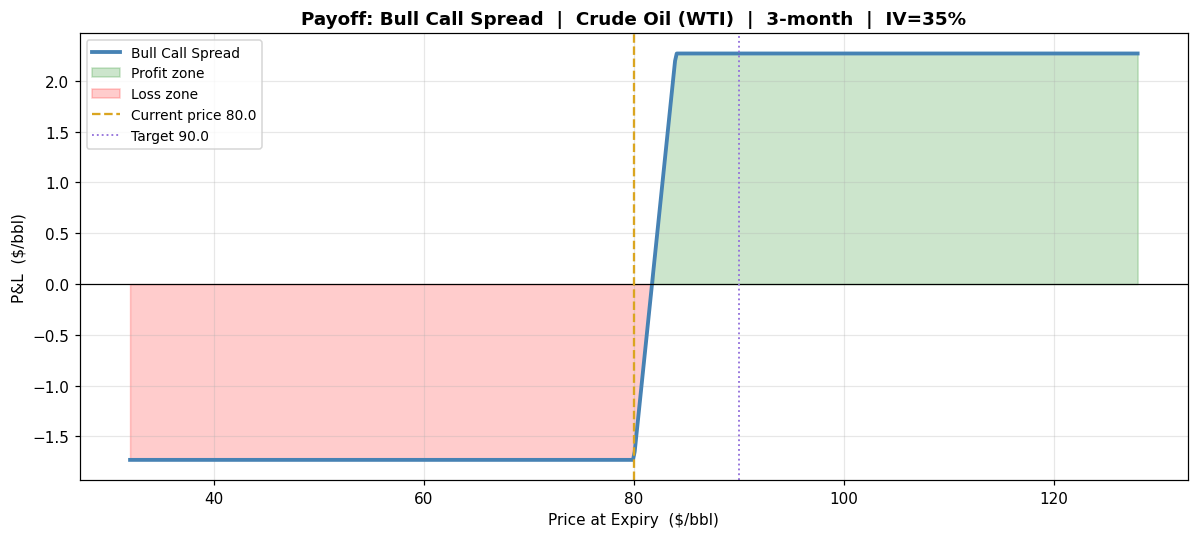

Strategy plotted: Bull Call Spread (score 10/10)
Net premium: +1.73 (debit)  (2.2% of spot)


In [7]:
# ── Plot payoff of top-ranked strategy at various prices ────────────────────

top_strategy = results[0][1]  # use top scorer

S_range = np.linspace(S * 0.4, S * 1.6, 600)
K_atm   = S
K_5otm  = S * 1.05
K_5itp  = S * 0.95
K_10otm = S * 1.10
K_10itp = S * 0.90

# Net premium for each leg
c_atm   = bs_call(S, K_atm,   T, r, iv)
p_atm   = bs_put( S, K_atm,   T, r, iv)
c_5otm  = bs_call(S, K_5otm,  T, r, iv)
p_5otm  = bs_put( S, K_5itp,  T, r, iv)
c_10otm = bs_call(S, K_10otm, T, r, iv)
p_10otm = bs_put( S, K_10itp, T, r, iv)

payoff_map = {
    'Long Call':          np.maximum(S_range - K_atm,  0) - c_atm,
    'Short Call':        -np.maximum(S_range - K_atm,  0) + c_atm,
    'Long Put':           np.maximum(K_atm - S_range,  0) - p_atm,
    'Short Put':         -np.maximum(K_atm - S_range,  0) + p_atm,
    'Bull Call Spread':  (np.maximum(S_range - K_atm,  0)
                        - np.maximum(S_range - K_5otm, 0) - (c_atm - c_5otm)),
    'Bear Put Spread':   (np.maximum(K_5otm - S_range, 0)
                        - np.maximum(K_atm  - S_range, 0) - (p_5otm - p_atm)),
    'Long Straddle':     (np.maximum(S_range - K_atm,  0)
                        + np.maximum(K_atm  - S_range, 0) - c_atm - p_atm),
    'Short Straddle':   -(np.maximum(S_range - K_atm,  0)
                        + np.maximum(K_atm  - S_range, 0)) + c_atm + p_atm,
    'Long Strangle':     (np.maximum(S_range - K_5otm, 0)
                        + np.maximum(K_5itp - S_range, 0) - c_5otm - p_5otm),
    'Short Strangle':   -(np.maximum(S_range - K_5otm, 0)
                        + np.maximum(K_5itp - S_range, 0)) + c_5otm + p_5otm,
    'Iron Condor':      -(np.maximum(S_range - K_5otm, 0) - np.maximum(S_range - K_10otm, 0)
                        + np.maximum(K_5itp - S_range, 0) - np.maximum(K_10itp - S_range, 0))
                        + c_5otm - c_10otm + p_5otm - p_10otm,
    'Collar (producer)': (np.maximum(K_5itp - S_range, 0) - p_5otm
                        - np.maximum(S_range - K_5otm, 0) + c_5otm),
    'Protective Put':    (S_range - S) + np.maximum(K_5itp - S_range, 0) - p_5otm,
    'Covered Call':      (S_range - S) - np.maximum(S_range - K_5otm, 0) + c_5otm,
    'Calendar Spread':   np.where(
        np.abs(S_range - K_atm) < S * 0.08,
        (c_atm * 0.40) * np.exp(-((S_range - K_atm)**2) / (2*(S*0.05)**2)),
        -(c_atm * 0.35) * np.abs(S_range / S - 1)),
}

pnl = payoff_map.get(top_strategy, np.zeros_like(S_range))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(S_range, pnl, lw=2.5, color='steelblue', label=top_strategy)
ax.fill_between(S_range, pnl, 0, where=(pnl>0), alpha=0.2, color='green', label='Profit zone')
ax.fill_between(S_range, pnl, 0, where=(pnl<0), alpha=0.2, color='red',   label='Loss zone')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(S, color='goldenrod', lw=1.5, linestyle='--', label=f'Current price {S:.1f}')
if price_target != S:
    ax.axvline(price_target, color='mediumpurple', lw=1.2, linestyle=':', label=f'Target {price_target:.1f}')
ax.set_xlabel(f'Price at Expiry  ({comm["unit"]})')
ax.set_ylabel(f'P&L  ({comm["unit"]})')
ax.set_title(
    f'Payoff: {top_strategy}  |  {comm["name"]}  |  {horizon_months}-month  |  IV={iv*100:.0f}%',
    fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Strategy plotted: {top_strategy} (score {results[0][0]}/10)")
print(f"Net premium: {results[0][2]}  ({results[0][4]:.1f}% of spot)")

---
## Part 6 — Multi-Scenario Comparison

Run the cell below to compare P&L across **bull / base / bear** price scenarios for your top 3 strategies.

  Scenario                    Bull Call Spread    Covered Call        Protective Put    
  ────────────────────────  ──────────────────  ──────────────────  ──────────────────
  Bear  (-20%)              -1.73 $/bbl     -11.62 $/bbl     -7.29 $/bbl   
  Mild Bear (-10%)          -1.73 $/bbl     -3.61 $/bbl     -7.29 $/bbl   
  Base (0%)                 -1.73 $/bbl     ++4.24 $/bbl     -3.37 $/bbl   
  Mild Bull (+10%)          ++2.27 $/bbl     ++8.32 $/bbl     ++4.65 $/bbl   
  Bull  (+20%)              ++2.27 $/bbl     ++8.32 $/bbl     ++12.66 $/bbl   
  Strong Bull (+30%)        ++2.27 $/bbl     ++8.32 $/bbl     ++20.67 $/bbl   

  Unit: $/bbl per unit of underlying
  Horizon: 3 months  |  IV: 35%  |  Spot: 80.00


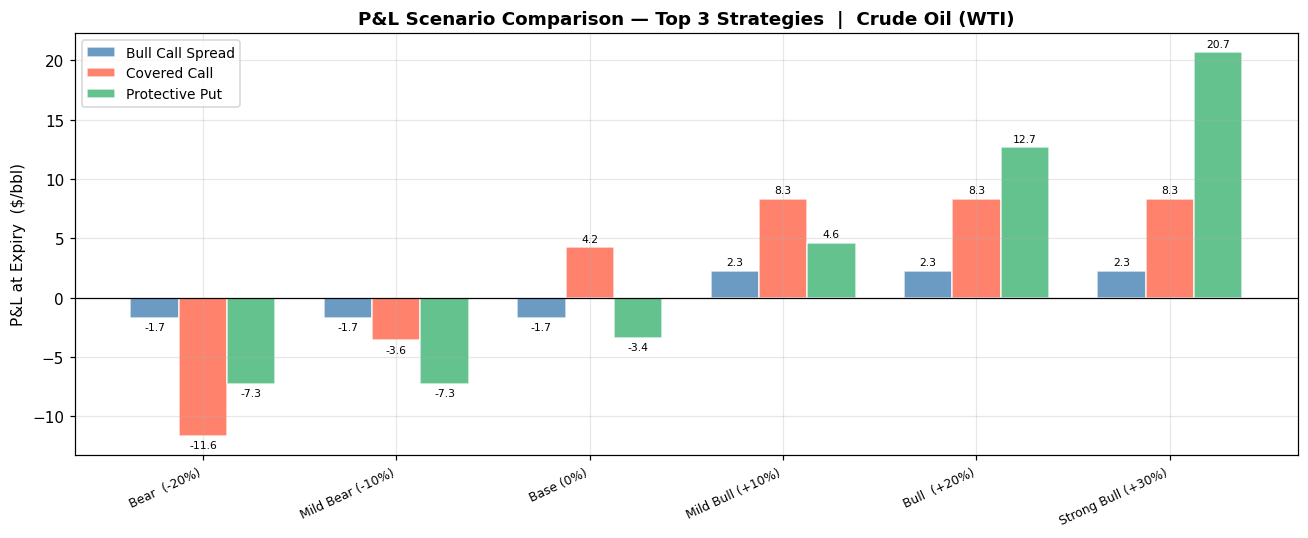

In [8]:
# ── Scenario Analysis: Bull / Base / Bear ───────────────────────────────────
# Price scenarios expressed as % move from current price
scenarios = {
    'Bear  (-20%)':  S * 0.80,
    'Mild Bear (-10%)': S * 0.90,
    'Base (0%)':     S * 1.00,
    'Mild Bull (+10%)': S * 1.10,
    'Bull  (+20%)':  S * 1.20,
    'Strong Bull (+30%)': S * 1.30,
}

top3 = [r[1] for r in results[:3]]

print(f"  {'Scenario':<24}  ", end='')
for strat in top3:
    print(f"  {strat[:18]:<18}", end='')
print()
print(f"  {'─'*24}  {'─'*18}  {'─'*18}  {'─'*18}")

scenario_data = {strat: [] for strat in top3}

for scenario_name, S_exp in scenarios.items():
    print(f"  {scenario_name:<24}", end='')
    for strat in top3:
        pnl_arr = payoff_map.get(strat, np.zeros_like(S_range))
        # interpolate at S_exp
        idx = np.argmin(np.abs(S_range - S_exp))
        pnl_val = pnl_arr[idx]
        scenario_data[strat].append(pnl_val)
        sign = '+' if pnl_val >= 0 else ''
        print(f"  {sign}{pnl_val:>+.2f} {comm['unit'][:5]:<5}   ", end='')
    print()

print(f"\n  Unit: {comm['unit']} per unit of underlying")
print(f"  Horizon: {horizon_months} months  |  IV: {iv*100:.0f}%  |  Spot: {S:.2f}")

# ── Bar chart comparison ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(scenarios))
width = 0.25
colors = ['steelblue', 'tomato', 'mediumseagreen']

for i, (strat, clr) in enumerate(zip(top3, colors)):
    vals = scenario_data[strat]
    bars = ax.bar(x + i*width, vals, width, label=strat, color=clr, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.3 if val>=0 else -1.2),
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(list(scenarios.keys()), rotation=25, ha='right', fontsize=8)
ax.set_ylabel(f'P&L at Expiry  ({comm["unit"]})')
ax.set_title(f'P&L Scenario Comparison — Top 3 Strategies  |  {comm["name"]}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 7 — When to Use What (Quick Decision Tree)

```
START: What's your market view?
│
├─ BULLISH
│   ├─ Strong conviction, want unlimited upside?  →  Long Call
│   ├─ Mild conviction, want to reduce cost?      →  Bull Call Spread
│   ├─ Own the physical commodity / stock?        →  Covered Call (income)
│   ├─ Want to buy commodity cheaper?             →  Short Put (cash-secured)
│   └─ Also think vol will rise?                  →  Long Call (pure premium buyer)
│
├─ BEARISH
│   ├─ Strong conviction, want full protection?   →  Long Put
│   ├─ Mild conviction, want to reduce cost?      →  Bear Put Spread
│   ├─ Producer hedging downside?                 →  Collar or Put Spread
│   ├─ Own commodity, want downside hedge?        →  Protective Put
│   └─ Bearish on vol too?                        →  Bear Call Spread (sell OTM call)
│
└─ NEUTRAL / RANGE-BOUND
    ├─ Want income, unlimited risk OK?            →  Short Straddle or Short Strangle
    ├─ Want income, defined risk?                 →  Iron Condor
    ├─ Think vol will RISE but no direction?      →  Long Straddle or Long Strangle
    └─ Near-term calm, long-term vol expansion?   →  Calendar Spread
```

### Commodity-Specific Decision Notes

**Crude Oil:**
- Pre-OPEC meeting → Long Straddle or Long Strangle (IV expansion play)
- E&P producer hedging production → Collar (sell call to fund put)
- Airline / refiner input hedging → Bull Call Spread on crude
- Bearish storage overhang view → Bear Put Spread

**LNG:**
- Utility buying winter cover → Asian Call Cap (OTC) on JKM
- Trader long cargo, fear price drop → Buy Put or Bear Put Spread on JKM
- Pre-winter vol play (Sep-Oct) → Long Straddle on JKM
- Fixed-price contract with optionality → Swaption (OTC)

**Coal:**
- Utility with coal supply contract, fear price rise → Bull Call Spread on API-2
- Miner hedging production revenue → Put Spread on Newcastle or API-4
- Power plant optimisation → Dark Spread Option (OTC) on coal vs power
- China demand vol play → Long Strangle on Newcastle (wide wings due to high IV)

---

## Part 8 — Key Rules of Thumb

```
╔══════════════════════════════════════════════════════════════════╗
║  When IV is HIGH (commodity in a spike)                         ║
║  → Prefer SELLING premium: spreads, iron condors, short strangles
║  → Avoid buying outright calls/puts (expensive)                 ║
║  → If you must buy, use a SPREAD to offset cost                 ║
╠══════════════════════════════════════════════════════════════════╣
║  When IV is LOW (calm market)                                   ║
║  → Prefer BUYING premium: straddles, strangles, long options    ║
║  → Cheap insurance window — buy protective puts now             ║
╠══════════════════════════════════════════════════════════════════╣
║  Gamma / Theta relationship                                     ║
║  → Long premium = +Gamma, −Theta  (you need moves to profit)   ║
║  → Short premium = −Gamma, +Theta (you need quiet to profit)   ║
╠══════════════════════════════════════════════════════════════════╣
║  Commodity-specific quirk: ASIAN OPTIONS                        ║
║  → Settle against monthly average, not spot at expiry           ║
║  → CHEAPER than vanilla (averaging reduces vol)                 ║
║  → Preferred for physical hedging (matches cargo invoice price) ║
╠══════════════════════════════════════════════════════════════════╣
║  DTE Management                                                 ║
║  → Theta accelerates last 30-45 DTE                            ║
║  → Premium sellers target 45 DTE entry, 21 DTE exit            ║
║  → Premium buyers often go 90-180 DTE to reduce theta burn     ║
╚══════════════════════════════════════════════════════════════════╝
```

---

> **See also:**  
> - `options_greeks_cheatsheet.ipynb` — Delta, Gamma, Theta, Vega, Rho with charts  
> - `black_scholes_commodities.ipynb` — Pricing models, vol surfaces for energy commodities